# Mapping charities to Justice Connect's four target subtypes

**Five things to know**

1. **~1,745 charities** across four cohorts: human rights 851, disaster preparedness 387, neighbourhood houses 312, injury prevention 237.
2. **~758 are addressable by reform** (don't already hold DGR): human rights 317, neighbourhood houses 234, disaster preparedness 129, injury prevention 78. Quote these, not the cohort sizes.
3. **Neighbourhood houses are the standout** — only 25% already endorsed. The other three cohorts leak ~two-thirds to existing DGR.
4. **Justice Connect's "68% of human-rights charities lack DGR" is a different population, not an error.** It matches charities whose *only* subtype is human rights (73% without DGR). Our 851-strong cohort includes multi-subtype charities — 376 are also PBIs, and 96% of those already hold DGR via the PBI category.
5. **This mapping is the targeting layer** for the event study (median +30% donation uplift) and the ancillary pool ($1,527m/yr): addressable counts convert sector-wide evidence into campaign-specific claims.

Built by `build_charity_target_subtypes()` in `R/build_target_subtypes.R` → `data/analytical/charity_target_subtypes.csv`. Definitions frozen 2026-07-09 (`docs/methodology.md`).

**Three auditable sources** — nothing is auto-included; every rule is human-reviewed before it counts:

| Source | Cohort | Mechanism |
|---|---|---|
| Register boolean | human_rights | The ACNC's own "promoting or protecting human rights" purpose flag |
| Whitelisted rules | other three | Name keywords + CLASSIE program classes (AIS 2021–24), promoted from candidate only after review |
| Manual mapping | any | Hand-curated ABN list — currently empty |

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

DATA = "../../data/analytical"

subtypes = pd.read_csv(f"{DATA}/charity_target_subtypes.csv", dtype={"abn": str})
rules = pd.read_csv("../../lookups/target_subtype_rules.csv")
master = pd.read_csv(f"{DATA}/charity_master.csv", usecols=["abn", "has_dgr"], dtype={"abn": str})

print(f"Mapping rows (abn x subtype x provenance): {len(subtypes):,}")
print(f"Distinct charities across all four cohorts: {subtypes['abn'].nunique():,}")
print(f"Rules on file: {len(rules)} ({(rules['status'] == 'whitelisted').sum()} whitelisted, "
      f"{(rules['status'] == 'candidate').sum()} candidate / not applied)")

Mapping rows (abn x subtype x provenance): 1,847
Distinct charities across all four cohorts: 1,745
Rules on file: 21 (13 whitelisted, 8 candidate / not applied)


## The mapping at a glance

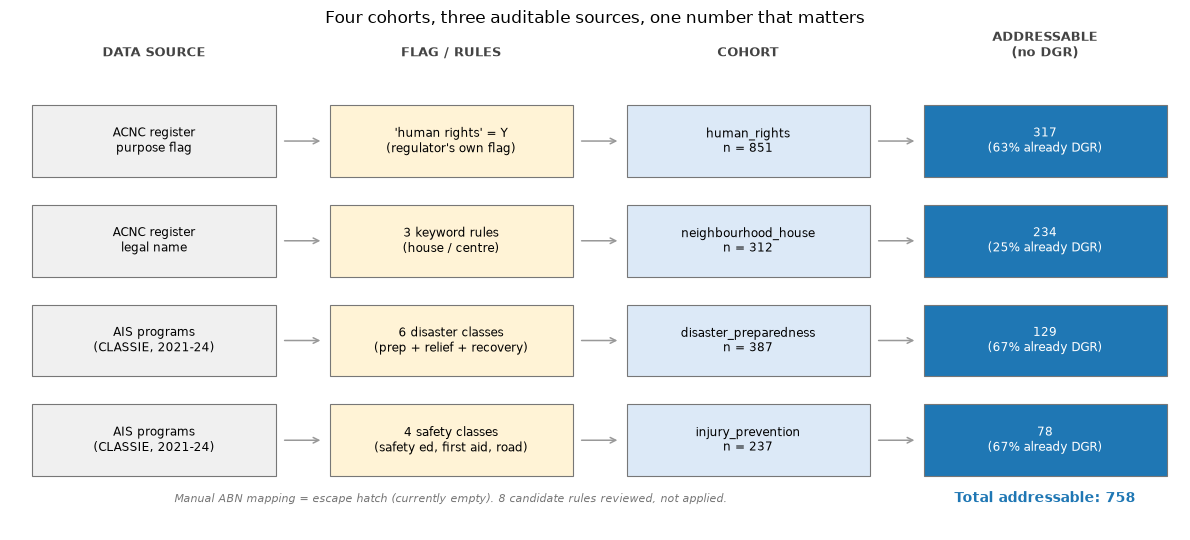

In [12]:
fig, ax = plt.subplots(figsize=(12, 5.5))
ax.axis("off")
ax.set_xlim(-1.6, 11.4)
ax.set_ylim(-0.9, 4.1)

def node(x, y, text, fc, tc="black", w=2.7, h=0.72):
    ax.add_patch(plt.Rectangle((x - w/2, y - h/2), w, h, fc=fc, ec="#777",
                               lw=0.8, zorder=2))
    ax.text(x, y, text, ha="center", va="center", fontsize=8.5, color=tc, zorder=3)

def link(x0, x1, y):
    ax.annotate("", (x1 - 1.42, y), (x0 + 1.42, y),
                arrowprops=dict(arrowstyle="->", color="#999", lw=1.1))

COLS = [0, 3.3, 6.6, 9.9]
for x, hdr in zip(COLS, ["DATA SOURCE", "FLAG / RULES", "COHORT", "ADDRESSABLE\n(no DGR)"]):
    ax.text(x, 3.85, hdr, ha="center", fontsize=9, fontweight="bold", color="#444")

ROWS = [
    ("ACNC register\npurpose flag",       "'human rights' = Y\n(regulator's own flag)",       "human_rights\nn = 851",          "317\n(63% already DGR)", 3.0),
    ("ACNC register\nlegal name",         "3 keyword rules\n(house / centre)",                 "neighbourhood_house\nn = 312",   "234\n(25% already DGR)", 2.0),
    ("AIS programs\n(CLASSIE, 2021-24)",  "6 disaster classes\n(prep + relief + recovery)",    "disaster_preparedness\nn = 387", "129\n(67% already DGR)", 1.0),
    ("AIS programs\n(CLASSIE, 2021-24)",  "4 safety classes\n(safety ed, first aid, road)",    "injury_prevention\nn = 237",     "78\n(67% already DGR)",  0.0),
]
for src, rule, coh, addr, y in ROWS:
    node(COLS[0], y, src, "#f0f0f0")
    node(COLS[1], y, rule, "#fff3d6")
    node(COLS[2], y, coh, "#dce9f7")
    node(COLS[3], y, addr, "#1f77b4", tc="white")
    for a, b in zip(COLS[:-1], COLS[1:]):
        link(a, b, y)

ax.text(3.3, -0.62, "Manual ABN mapping = escape hatch (currently empty). 8 candidate rules reviewed, not applied.",
        ha="center", fontsize=8, color="#777", style="italic")
ax.text(9.9, -0.62, "Total addressable: 758", ha="center", fontsize=10,
        fontweight="bold", color="#1f77b4")
ax.set_title("Four cohorts, three auditable sources, one number that matters", fontsize=12)
plt.tight_layout()
plt.show()

## Cohort sizes by provenance

human_rights comes entirely from the register flag; the other three from whitelisted rules.

In [2]:
cohorts = subtypes.drop_duplicates(["abn", "subtype"])

prov = (subtypes.drop_duplicates(["abn", "subtype", "source"])
        .pivot_table(index="subtype", columns="source", values="abn",
                     aggfunc="nunique", fill_value=0))
prov["distinct_charities"] = cohorts.groupby("subtype")["abn"].nunique()
prov

source,register_boolean,rule,distinct_charities
subtype,,,
disaster_preparedness,0,387,387
human_rights,851,0,851
injury_prevention,0,237,237
neighbourhood_house,0,312,312


## Which rules do the work

Charities per whitelisted rule (a charity can match several), with the review note recorded at promotion.

In [3]:
rule_counts = (subtypes[subtypes["source"] == "rule"]
               .groupby("rule_id")["abn"].nunique()
               .rename("n_charities"))

applied = (rules[rules["status"] == "whitelisted"]
           .merge(rule_counts, left_on="rule_id", right_index=True, how="left")
           .fillna({"n_charities": 0}).astype({"n_charities": int})
           [["rule_id", "subtype", "rule_type", "pattern", "n_charities", "notes"]]
           .sort_values(["subtype", "n_charities"], ascending=[True, False]))

with pd.option_context("display.max_colwidth", 110):
    display(applied.reset_index(drop=True))

,rule_id,subtype,rule_type,pattern,n_charities,notes
0,DP-CLASSIE-03,disaster_preparedness,classie_classification,Disaster relief,128,Relief is response not preparedness — review whether in scope for the campaign definition.
1,DP-CLASSIE-02,disaster_preparedness,classie_classification,Disasters and emergency management,101,CLASSIE parent-level classification for disaster/emergency management programs.
2,DP-CLASSIE-09,disaster_preparedness,classie_classification,Floods,53,Flood-specific programs (mostly relief after 2022 floods — review).
3,DP-CLASSIE-08,disaster_preparedness,classie_classification,Bushfires,49,Bushfire-specific programs (mostly relief/recovery after 2019-20 fires — review).
4,DP-CLASSIE-04,disaster_preparedness,classie_classification,Disaster recovery,48,Recovery is post-event — review whether in scope.
5,DP-CLASSIE-01,disaster_preparedness,classie_classification,Disaster preparedness,38,"CLASSIE program classification, exact match. Core preparedness activity."
6,IP-CLASSIE-01,injury_prevention,classie_classification,Safety education,126,Largest injury-prevention-relevant CLASSIE class (~140 programs/yr).
7,IP-CLASSIE-02,injury_prevention,classie_classification,First aid training,61,First aid training providers (St John etc.).
8,IP-CLASSIE-03,injury_prevention,classie_classification,Motor vehicle safety,44,Road safety programs.
9,IP-CLASSIE-04,injury_prevention,classie_classification,Traffic safety,35,Road/traffic safety programs.


In [4]:
# Rules reviewed but deliberately NOT applied (remain in the candidate reports for future review)
with pd.option_context("display.max_colwidth", 110):
    display(rules.loc[rules["status"] == "candidate",
                      ["rule_id", "subtype", "rule_type", "pattern", "notes"]]
            .reset_index(drop=True))

,rule_id,subtype,rule_type,pattern,notes
0,DP-CLASSIE-05,disaster_preparedness,classie_classification,Disasters,Generic CLASSIE bucket; programs not further classified.
1,DP-CLASSIE-06,disaster_preparedness,classie_classification,Search and rescue,"Volunteer SAR organisations (marine rescue, alpine, etc.)."
2,DP-CLASSIE-07,disaster_preparedness,classie_classification,Fire prevention and control,Rural fire brigades and fire-prevention programs.
3,DP-CLASSIE-10,disaster_preparedness,classie_classification,Non-natural disasters,Small count; review individually.
4,IP-CLASSIE-05,injury_prevention,classie_classification,Public safety,Broad class — review member list for relevance.
5,IP-CLASSIE-06,injury_prevention,classie_classification,Home safety,Small count.
6,IP-CLASSIE-07,injury_prevention,classie_classification,Pedestrian safety,Small count.
7,IP-CLASSIE-08,injury_prevention,classie_classification,Bicycle safety,Small count.


## Key definitional decisions

- Disaster **relief/recovery counts as preparedness**; first aid counts as injury prevention — responders are largely the preparers.
- Adjacent **road-safety CLASSIE classes merged** (motor vehicle + traffic safety): a taxonomy artefact, not a real split.
- **Candidate rules excluded, not forgotten** (SAR, fire brigades, public safety) — promotable later without code changes.
- These counts **supersede the stakeholder-brief figures** (259 / 86 / 79 / 847): CLASSIE sees what charities *do*, not what they're called.

## DGR leakage: the number that matters

Reform only helps cohort members **without** existing DGR. Joining to ABR endorsement status:

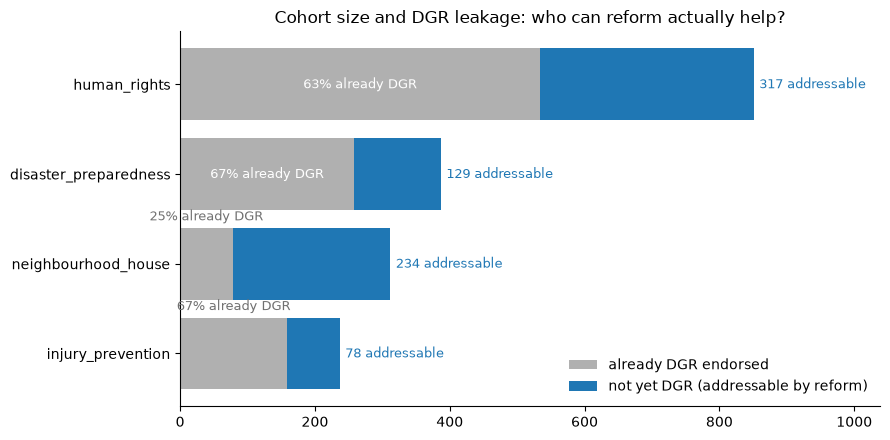

,cohort_size,already_dgr,addressable,pct_already_dgr
subtype,,,,
injury_prevention,237,159,78,67.1%
neighbourhood_house,312,78,234,25.0%
disaster_preparedness,387,258,129,66.7%
human_rights,851,534,317,62.7%


In [7]:
d = (cohorts.merge(master, on="abn", how="left")
     .assign(has_dgr=lambda x: x["has_dgr"].astype(str).str.upper().eq("TRUE")))

leak = (d.groupby("subtype")
        .agg(cohort_size=("abn", "nunique"),
             already_dgr=("has_dgr", "sum"))
        .assign(addressable=lambda x: x["cohort_size"] - x["already_dgr"],
                pct_already_dgr=lambda x: x["already_dgr"] / x["cohort_size"])
        .sort_values("cohort_size"))

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(leak.index, leak["already_dgr"], color="#b0b0b0", label="already DGR endorsed")
ax.barh(leak.index, leak["addressable"], left=leak["already_dgr"],
        color="#1f77b4", label="not yet DGR (addressable by reform)")
for i, (_, r) in enumerate(leak.iterrows()):
    lbl = f"{r['pct_already_dgr']:.0%} already DGR"
    if r["already_dgr"] > 250:
        ax.annotate(lbl, (r["already_dgr"] / 2, i), ha="center", va="center",
                    fontsize=9, color="white")
    else:
        ax.annotate(lbl, (r["already_dgr"] / 2, i + 0.45), ha="center", va="bottom",
                    fontsize=9, color="#707070")
    ax.annotate(f"{int(r['addressable'])} addressable",
                (r["cohort_size"] + 8, i), va="center", fontsize=9, color="#1f77b4")
ax.set_xlim(0, leak["cohort_size"].max() * 1.22)
ax.set_title("Cohort size and DGR leakage: who can reform actually help?")
ax.legend(loc="lower right", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

leak_display = leak.copy()
leak_display["pct_already_dgr"] = leak_display["pct_already_dgr"].map("{:.1%}".format)
leak_display

## Cohort scorecard

| Cohort | Total | With DGR | Without (addressable) | Limitations |
|---|--:|--:|--:|---|
| **human_rights** | 851 | 534 | **317** | • Register flag includes multi-subtype charities (376 also PBI)<br>• JC's sole-subtype view gives a different, smaller population<br>• Register vintage — recent registrations/revocations lag |
| **neighbourhood_house** | 312 | 78 | **234** | • Name-keyword rules miss houses without "house/centre" in legal name<br>• ~750 council/umbrella-auspiced houses aren't ACNC-registered — invisible to us<br>• Counts charities, not physical houses (ANHCA: ~1,064) |
| **disaster_preparedness** | 387 | 258 | **129** | • Depends on AIS CLASSIE programs — 2021+ lodgers only, so a **lower bound**<br>• Includes relief/recovery by design (definitional choice)<br>• Small/non-lodging charities undercounted |
| **injury_prevention** | 237 | 159 | **78** | • Same AIS dependency — lower bound<br>• Candidate classes (SAR, fire brigades, public safety) not counted<br>• Prevention slice of health subtype can't be verified externally |
| **Total** | 1,787\* | 1,029 | **758** | • All counts = currently registered charities only<br>• Dollar modelling additionally needs AIS financials |

\* Rows sum across cohorts; 1,745 distinct charities (a few sit in more than one cohort).

## Benchmarking against other sources

| Cohort | Ours | External | Reconciliation |
|---|---|---|---|
| **neighbourhood_house** | 312, 25% DGR → 234 addressable | ANHCA ~1,064 houses; JC ~1,000, ⅓ with DGR → 650–700 without | DGR *rate* agrees. Count gap = units: they count physical houses (many council-auspiced, not ACNC-registered); we count registered charities. |
| **human_rights** | 851, 63% *with* DGR | JC: 68% *without* DGR | Different populations — tested below. |
| **disaster_preparedness** | 387, 67% DGR → 129 addressable | JC: "no way of knowing"; CharityGuide ~483 (broader scope) | CLASSIE programs answer the question subtype data can't. |
| **injury_prevention** | 237, 67% DGR → 78 addressable | JC: health subtype 557 without DGR, "can't tell which relate to prevention" | Same — CLASSIE isolates the prevention slice; ours cuts across subtypes. |

### The human-rights "68% without DGR" — resolved as a population difference

Both cells below use one row per ABN. First: DGR definition doesn't explain it. Second: JC's Data Explorer buckets multi-subtype charities separately, so their 68% describes charities whose *only* subtype is human rights.

In [9]:
# Probe the human_rights discrepancy: JC says 68% WITHOUT DGR, we find 62.7% WITH.
# Test whether a narrower DGR definition (endorsed in own right vs via an
# operated fund) reproduces their number.
m2 = pd.read_csv(f"{DATA}/charity_master.csv",
                 usecols=["abn", "has_dgr", "dgr_item_number", "has_item1_fund"],
                 dtype={"abn": str})
print(f"charity_master rows: {len(m2):,}, distinct ABNs: {m2['abn'].nunique():,}")
print(f"duplicate-ABN rows agree on has_dgr: {(m2.groupby('abn')['has_dgr'].nunique() == 1).all()}")

m2 = m2.drop_duplicates("abn")
hr = (cohorts[cohorts["subtype"] == "human_rights"]
      .merge(m2, on="abn", how="left")
      .assign(has_dgr=lambda x: x["has_dgr"].astype(str).str.upper().eq("TRUE"),
              has_item1_fund=lambda x: x["has_item1_fund"].astype(str).str.upper().eq("TRUE"),
              own_right=lambda x: x["dgr_item_number"] == 1,
              fund_only=lambda x: x["has_item1_fund"] & x["dgr_item_number"].isna()))

n = len(hr)
print(f"\nhuman_rights cohort, one row per ABN (n={n}):")
print(f"  any current ABR endorsement:                  {hr['has_dgr'].mean():.1%} with DGR")
print(f"  endorsed in own right (DGR listing, Item 1):  {hr['own_right'].mean():.1%}")
print(f"  endorsed only via an operated fund:           {hr['fund_only'].mean():.1%}")
print(f"  no endorsement at all:                        {(~hr['has_dgr'] & ~hr['fund_only']).mean():.1%}")
print(f"\nJustice Connect email: 68% of the ACNC human-rights subtype WITHOUT DGR")

charity_master rows: 65,430, distinct ABNs: 64,850
duplicate-ABN rows agree on has_dgr: True

human_rights cohort, one row per ABN (n=852):
  any current ABR endorsement:                  62.7% with DGR
  endorsed in own right (DGR listing, Item 1):  55.5%
  endorsed only via an operated fund:           3.5%
  no endorsement at all:                        37.3%

Justice Connect email: 68% of the ACNC human-rights subtype WITHOUT DGR


In [10]:
# Population test: JC's Data Explorer buckets multi-subtype charities under
# "multiple", so their 68% likely covers charities whose ONLY subtype is HR.
SUBTYPE_COLS = ["pbi", "hpc", "preventing_or_relieving_suffering_of_animals",
                "advancing_culture", "advancing_education", "advancing_health",
                "promote_or_oppose_a_change_to_law_government_poll_or_prac",
                "advancing_natual_environment", "promoting_or_protecting_human_rights",
                "purposes_beneficial_to_ther_general_public_and_other_analogous",
                "promoting_reconciliation_mutual_respect_and_tolerance",
                "advancing_religion", "advancing_social_or_public_welfare",
                "advancing_security_or_safety_of_australia_or_australian_public"]

m3 = (pd.read_csv(f"{DATA}/charity_master.csv",
                  usecols=["abn", "has_dgr"] + SUBTYPE_COLS, dtype=str)
      .drop_duplicates("abn"))
hr3 = m3[m3["promoting_or_protecting_human_rights"] == "Y"].copy()
others = [c for c in SUBTYPE_COLS if c != "promoting_or_protecting_human_rights"]
hr3["n_other"] = (hr3[others] == "Y").sum(axis=1)
hr3["dgr"] = hr3["has_dgr"].str.upper() == "TRUE"

only, multi = hr3[hr3["n_other"] == 0], hr3[hr3["n_other"] > 0]
pbi = multi[multi["pbi"] == "Y"]
print(f"HR is the ONLY subtype:  n={len(only):>4}, {1 - only['dgr'].mean():.0%} WITHOUT DGR  <- JC's likely population (68%)")
print(f"HR + other subtypes:     n={len(multi):>4}, {1 - multi['dgr'].mean():.0%} without DGR")
print(f"  of which also PBI:     n={len(pbi):>4}, {1 - pbi['dgr'].mean():.0%} without DGR (DGR comes via PBI, not the HR purpose)")

HR is the ONLY subtype:  n=  48, 73% WITHOUT DGR  <- JC's likely population (68%)
HR + other subtypes:     n= 803, 35% without DGR
  of which also PBI:     n= 376, 4% without DGR (DGR comes via PBI, not the HR purpose)


**Finding: both numbers are right — for different populations.**

- Sole-subtype human-rights charities (n=48): **73% without DGR** — this matches JC's 68%.
- Our full cohort (n=851) includes 803 multi-subtype charities (35% without DGR); 376 are also PBIs, and only 4% of those lack DGR — their endorsement comes via the PBI category, since "promoting human rights" is not itself a DGR category.

**Implication:** JC's 68% describes a small sole-purpose group; our 317 addressable is the campaign-relevant count. Worth confirming the Data Explorer filter with JC, but no contradiction to resolve.

Their other estimates triangulate well: the neighbourhood-house DGR rate matches, and for disaster/injury prevention our CLASSIE method is the only quantified estimate on the table — consistent with their framing that *"the development of a methodology to model the benefits is something that is exceptionally useful."*

## Where this fits with the event study and ancillary pool work

| Piece | Question | Headline |
|---|---|---|
| **Subtype mapping** (this notebook) | *Who* can reform reach? | 758 addressable across four cohorts |
| **Event study** | How much *extra giving* does endorsement create? | Median **+30%** real donation growth, strongest for small charities |
| **Ancillary pool** | What *existing money* becomes accessible? | **$1,527m/yr** DGR-restricted; expansion gainers could access $109m–$600m/yr |

1. **The mapping is the join key.** Both quantitative pieces are sector-wide by necessity; the addressable counts convert them into cohort-specific claims. It already stratifies `dgr_gap_analysis`, `dgr_incumbent_exposure` and `reform_scenarios`.
2. **The two channels are additive without double counting** — pie growth (new donations) vs redistribution (existing pool dollars) — and both apply only to the addressable segment.
3. **Cautions:** switchers self-selected, so uplift applications are scenarios, not predictions; pool numbers are access under a mechanical allocation rule, not predicted flows.

**Bottom line:** the mapping is the targeting layer, and its main contribution is the leakage-adjusted addressable base — the honest denominator for both the +30% uplift and the pool-access ranges.